In [63]:
# mount google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/AdvDL/stellar-parameter-prediction')


In [65]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = '/content/drive/My Drive/AdvDL/stellar-parameter-prediction/data'


In [66]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
from CNNhelper import normalize, denormalize, train_model, get_normalized_data, evaluate_model


In [67]:
import torch
import torch.nn as nn

class TinyCNN(nn.Module):
    def __init__(self, nLabels):
        super(TinyCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),  # Input: (B, 1, L)
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.AvgPool1d(2),                            # Output: (B, 16, L/2)

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.AvgPool1d(2),                            # Output: (B, 32, L/4)

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AvgPool1d(2),                            # Output: (B, 64, L/8)

            nn.AdaptiveAvgPool1d(1),                    # Output: (B, 64, 1)
            nn.Flatten(),                               # Output: (B, 64)
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, nLabels*2)                      # Output: (B, nLabels*2) --- doubled number of output labels to predict both nominal value (mu) and uncertainty (log(sigma))
        )

    def forward(self, x):
        return self.model(x)

In [68]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
print(f"spectra shape: {spectra.shape}")
print(f"labels shape: {labels.shape}")
# spectra length is 16384 and we are predicting 3 labels
# we have 8914 samples

spectra shape: (8914, 16384)
labels shape: (8914, 3)


In [69]:
# plot a few spectra
"""%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()"""

'%matplotlib inline\n# plot a few spectra\nfor i in range(10):\n  fig, ax = plt.subplots(1, 1, figsize=(10, 5))\n  ax.plot(spectra[i], lw=1)\n  ax.set_title(f"Star {i}")\n  plt.tight_layout()'

In [70]:
#Model implementation:

# Hyperparameters
learning_rate = 2e-4
batch_size = 32
num_epochs = 100
patience = 10 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
train_fraction = 0.7 # Fraction of the data used for training
val_fraction = 0.15 # Fraction of the data used for validation

In [71]:
# Call the helper function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

In [72]:
# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

In [73]:
# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor) #8914 samples
train_size = int(train_fraction * total_samples) #0.7 * 8914 = 6249
val_size = int(val_fraction * total_samples) #0.15 * 8914 = 1337
test_size = total_samples - train_size - val_size # 8914 - 6249 - 1337 = 1328
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

In [74]:
# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cuda


TinyCNN(
  (model): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (12): AdaptiveAvgPool1d(output_size=1)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): ReLU()
    (16): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [75]:
# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Model selection
model_choice = 'TinyCNN'
if model_choice == 'TinyCNN':
    model = TinyCNN(n_labels)
else:
    raise ValueError("Invalid model choice. Please select 'TinyCNN'.")
model = model.to(device)


# Print the model summary before moving it to the device
summary(model, input_size=(1, spectra_length))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 16, 16384]              96
              ReLU-2            [-1, 16, 16384]               0
       BatchNorm1d-3            [-1, 16, 16384]              32
         AvgPool1d-4             [-1, 16, 8192]               0
            Conv1d-5             [-1, 32, 8192]           2,592
              ReLU-6             [-1, 32, 8192]               0
       BatchNorm1d-7             [-1, 32, 8192]              64
         AvgPool1d-8             [-1, 32, 4096]               0
            Conv1d-9             [-1, 64, 4096]           6,208
             ReLU-10             [-1, 64, 4096]               0
      BatchNorm1d-11             [-1, 64, 4096]             128
        AvgPool1d-12             [-1, 64, 2048]               0
AdaptiveAvgPool1d-13                [-1, 64, 1]               0
          Flatten-14                   

In [76]:
# Define the loss function
def nll_loss(inputs, labels, model):
    """
    Computes the Gaussian Negative Log-Likelihood loss.

    The model outputs 6 values per sample: 3 means and 3 log standard deviations.
    """
    predictions = model(inputs)  # shape: (B, 6)
    n = predictions.shape[1] // 2  # n=3 --- 3 for μ, 3 for log σ

    mu = predictions[:, :n]
    log_sigma = predictions[:, n:]

    # Compute the NLL
    mse_term = ((labels - mu)**2) / torch.exp(2 * log_sigma)
    nll = log_sigma + 0.5 * mse_term #nll is a per-sample, per-label loss matrix, tensor shape (B, 3)

    return nll.mean()


In [77]:
# Train the model
loss_function = nll_loss
train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device)

Epoch [1/100], Step [190/195], Loss: -0.5876
Epoch [1/100], Train Loss: -0.1830, Val Loss: -0.6997, Time: 2.40 seconds
Epoch [2/100], Step [190/195], Loss: -0.7511
Epoch [2/100], Train Loss: -0.7731, Val Loss: -0.8892, Time: 2.40 seconds
Epoch [3/100], Step [190/195], Loss: -1.0755
Epoch [3/100], Train Loss: -0.8815, Val Loss: -0.9574, Time: 2.41 seconds
Epoch [4/100], Step [190/195], Loss: -0.9258
Epoch [4/100], Train Loss: -0.9423, Val Loss: -1.0121, Time: 2.41 seconds
Epoch [5/100], Step [190/195], Loss: -1.1237
Epoch [5/100], Train Loss: -0.9834, Val Loss: -1.0413, Time: 2.41 seconds
Epoch [6/100], Step [190/195], Loss: -1.2051
Epoch [6/100], Train Loss: -1.0306, Val Loss: -1.0651, Time: 2.41 seconds
Epoch [7/100], Step [190/195], Loss: -1.1605
Epoch [7/100], Train Loss: -1.0641, Val Loss: -1.0657, Time: 2.42 seconds
Epoch [8/100], Step [190/195], Loss: -1.0884
Epoch [8/100], Train Loss: -1.1068, Val Loss: -0.9878, Time: 2.42 seconds
Epoch [9/100], Step [190/195], Loss: -1.2411
Epo

In [78]:
#Load the best model
if best_model is not None:
    model.load_state_dict(best_model)
    torch.save(best_model, f'models/{model_choice}_best.pth')
else:
    print("⚠️ Warning: best_model is None. Training likely failed due to NaNs.")
model.to(device)
# save the best model to the "models" directory
if not os.path.exists('models'):
    os.makedirs('models')
torch.save(best_model, f'models/{model_choice}_best.pth')
model.to(device)

TinyCNN(
  (model): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (12): AdaptiveAvgPool1d(output_size=1)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=64, out_features=64, bias=True)
    (15): ReLU()
    (16): Linear(in_features=64, out_features=6, bias=True)
  )
)

In [79]:
def evaluate_model_with_uncertainty(model, test_loader, device):
    """
    Evaluate model predictions and uncertainty calibration via pull distributions.
    """
    print("Evaluating model with uncertainty on the test dataset...")
    model.eval()

    all_mu = []
    all_log_sigma = []
    all_labels = []
    all_pulls = []

    with torch.no_grad():
        for batch_spectra, batch_labels in test_loader:
            batch_spectra = batch_spectra.to(device).unsqueeze(1)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_spectra)
            mu = outputs[:, :3]
            log_sigma = outputs[:, 3:]
            sigma = torch.exp(log_sigma)

            pulls = (batch_labels - mu) / sigma

            all_mu.append(mu.cpu())
            all_log_sigma.append(log_sigma.cpu())
            all_labels.append(batch_labels.cpu())
            all_pulls.append(pulls.cpu())

    mu = torch.cat(all_mu).numpy()
    log_sigma = torch.cat(all_log_sigma).numpy()
    sigma = np.exp(log_sigma)
    labels = torch.cat(all_labels).numpy()
    pulls = torch.cat(all_pulls).numpy()

    return mu, sigma, labels, pulls


In [80]:
mu, sigma, labels, pulls = evaluate_model_with_uncertainty(model, test_loader, device)

Evaluating model with uncertainty on the test dataset...


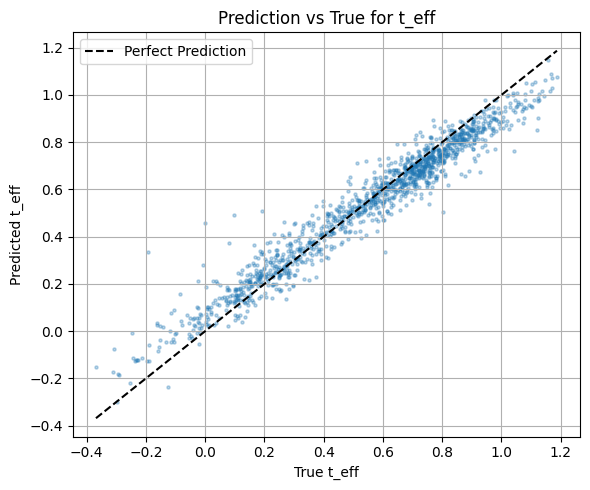

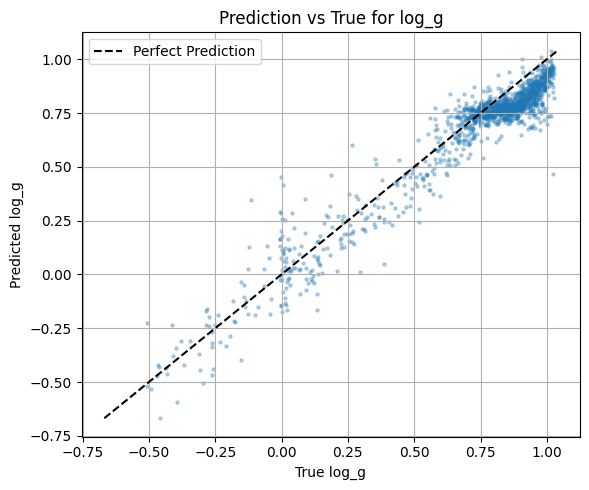

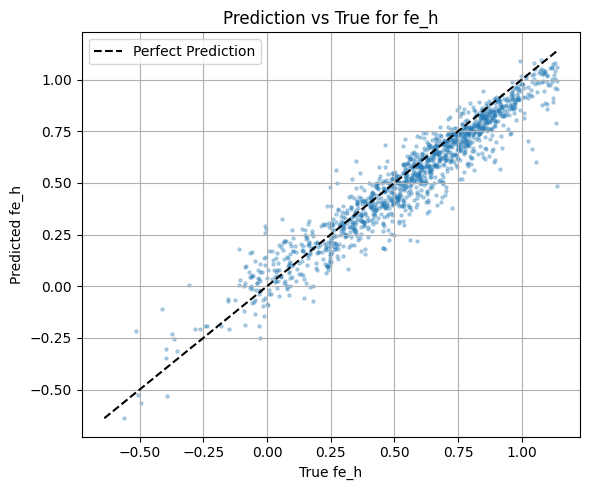

In [83]:
import matplotlib.pyplot as plt

for j in range(3):
    plt.figure(figsize=(6, 5))
    plt.scatter(labels[:, j], mu[:, j], alpha=0.3, s=5)
    min_val = min(labels[:, j].min(), mu[:, j].min())
    max_val = max(labels[:, j].max(), mu[:, j].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="Perfect Prediction")
    plt.xlabel(f"True {labelNames[j]}")
    plt.ylabel(f"Predicted {labelNames[j]}")
    plt.title(f"Prediction vs True for {labelNames[j]}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


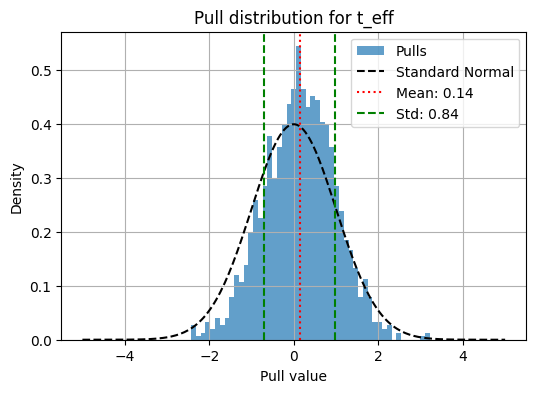

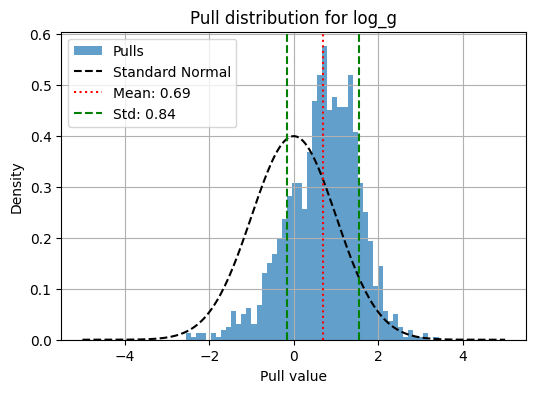

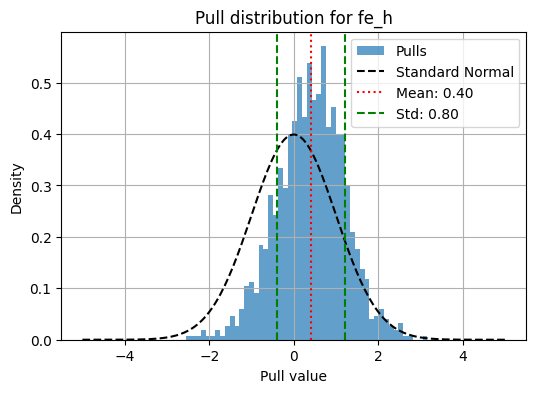

In [81]:
import scipy.stats as stats

for j in range(3):
    plt.figure(figsize=(6, 4))
    plt.hist(pulls[:, j], bins=50, density=True, alpha=0.7, label='Pulls')
    x = np.linspace(-5, 5, 200)
    plt.plot(x, stats.norm.pdf(x), 'k--', label='Standard Normal')
    plt.axvline(pulls[:, j].mean(), color='r', linestyle=':', label=f'Mean: {pulls[:, j].mean():.2f}')
    plt.axvline(pulls[:, j].mean() + pulls[:, j].std(), color='g', linestyle='--', label=f'Std: {pulls[:, j].std():.2f}')
    plt.axvline(pulls[:, j].mean() - pulls[:, j].std(), color='g', linestyle='--')
    plt.title(f"Pull distribution for {labelNames[j]}")
    plt.xlabel("Pull value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


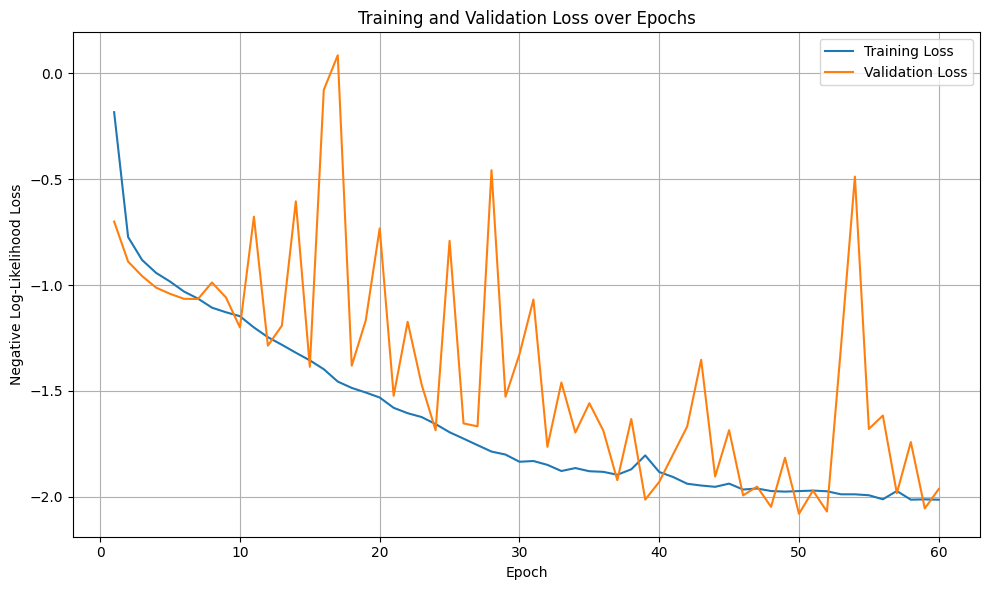

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
